# Дискретно-событийная модель SIR: рождение и смерть

Добавим в модель демографию: каждый человек умирает с интенсивностью
$\mu$, а новые здоровые люди рождаются с постоянной интенсивностью
$\mu N_0$, так что размер популяции в среднем не меняется.
Приток новых восприимчивых позволяет инфекции не исчезнуть после
первой волны, и система выходит на эндемическое равновесие.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(SIRDES) || include(srcdir("sir_model.jl"))
using .SIRDES
using Random, Plots, DataFrames, CSV

script_name = "sir_des_demography"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab08/project/data"

## Параметры модели

Параметры заражения те же, что и раньше. Средняя продолжительность
жизни равна $1/\mu = 20$, моделирование идёт до момента 200.

In [2]:
tmax = 200.0
u0 = [990, 10, 0]
p = [0.05, 10.0, 0.25]
μ = 0.05

0.05

## Эндемическое равновесие

В детерминированной модели равновесие равно
$S^* = N(\gamma + \mu)/(\beta c)$, $I^* = \mu (N - S^*)/(\gamma + \mu)$,
$R^* = N - S^* - I^*$.

In [3]:
N0 = sum(u0)
S_star = N0 * (p[3] + μ) / (p[1] * p[2])
I_star = μ * (N0 - S_star) / (p[3] + μ)
R_star = N0 - S_star - I_star
println("Равновесие: S* = ", round(S_star, digits = 1), ", I* = ", round(I_star, digits = 1), ", R* = ", round(R_star, digits = 1))

Равновесие: S* = 600.0, I* = 66.7, R* = 333.3


## Дискретно-событийная модель

In [4]:
Random.seed!(1234)
m_dem = MakeXModel(u0, p; μ = μ)
activate_x(m_dem)
run_x(m_dem, tmax)
df_dem = out_x(m_dem)
CSV.write(datadir("sir_des_demography.csv"), df_dem)
println("Число событий: ", nrow(df_dem) - 1)
println("Больных в конце: ", df_dem.I[end])

Число событий: 28023
Больных в конце: 43


## Средние значения на втором отрезке времени

Сравним средние по времени значения на отрезке от 100 до 200
с равновесием детерминированной модели.

In [5]:
df_avg = DataFrame(
    group = ["S", "I", "R", "N"],
    des = [round(time_average(df_dem.t, df_dem[!, g], 100.0, tmax), digits = 1) for g in ["S", "I", "R", "N"]],
    theory = round.([S_star, I_star, R_star, N0], digits = 1),
)
println(df_avg)

4×3 DataFrame
 Row │ group   des      theory  
     │ String  Float64  Float64 
─────┼──────────────────────────
   1 │ S         597.8    600.0
   2 │ I          69.9     66.7
   3 │ R         331.2    333.3
   4 │ N         998.8   1000.0


## Детерминированная модель

In [6]:
df_dem_ode = sir_ode_extended(u0, p, tmax; μ = μ)

Row,t,S,E,I,R
,Float64,Float64,Float64,Float64,Float64
1,0.0,990.0,0.0,10.0,0.0
2,0.1,989.551,0.0,10.1968,0.251824
3,0.2,989.095,0.0,10.3972,0.507346
4,0.3,988.632,0.0,10.6014,0.766637
5,0.4,988.161,0.0,10.8093,1.02977
6,0.5,987.682,0.0,11.021,1.29683
7,0.6,987.196,0.0,11.2365,1.56788
8,0.7,986.701,0.0,11.4561,1.843
9,0.8,986.198,0.0,11.6796,2.12228


## Графики

Слева численность групп, справа отдельно число больных.
Пунктир --- детерминированная модель.

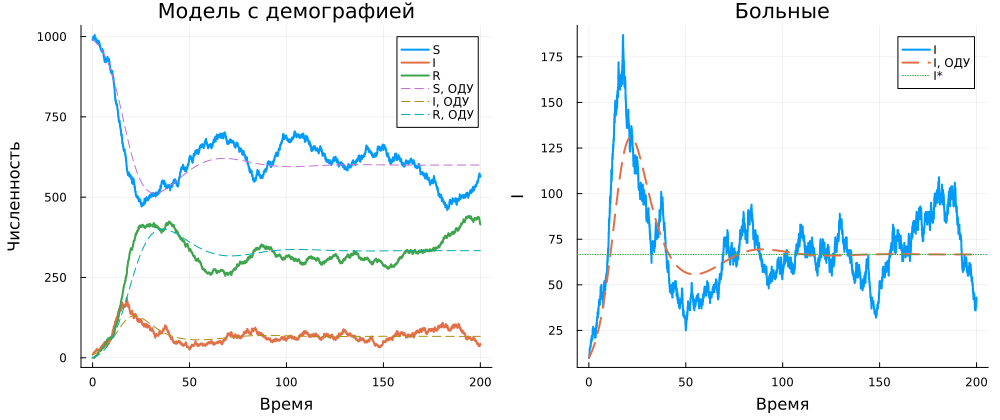

In [7]:
p1 = plot(df_dem.t, [df_dem.S df_dem.I df_dem.R], label = ["S" "I" "R"], xlabel = "Время", ylabel = "Численность", title = "Модель с демографией", linewidth = 2)
plot!(p1, df_dem_ode.t, [df_dem_ode.S df_dem_ode.I df_dem_ode.R], label = ["S, ОДУ" "I, ОДУ" "R, ОДУ"], linestyle = :dash)
p2 = plot(df_dem.t, df_dem.I, label = "I", xlabel = "Время", ylabel = "I", title = "Больные", linewidth = 2)
plot!(p2, df_dem_ode.t, df_dem_ode.I, label = "I, ОДУ", linestyle = :dash, linewidth = 2)
hline!(p2, [I_star], linestyle = :dot, label = "I*")
plt_dem = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
savefig(plt_dem, plotsdir("sir_des_demography.png"))
plt_dem